# 第 7 章 · 决策树与 KMeans

[章节网页](../ch7.html)

## 运行内容

- 调用 sklearn 决策树
- 调用 sklearn KMeans
- 输出模型结果和图

## 0. 环境与数据

In [1]:
# 准备运行时：本 notebook 内嵌所需源码和数据，不依赖在线封装文件。
import importlib.util
import subprocess
import sys
from pathlib import Path

INLINE_RUNTIME_FILES = {
  "labs/ch07/learning.py": "\"\"\"Chapter 7 learning demos — pedagogical API.\"\"\"\n\nfrom __future__ import annotations\n\nimport math\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom sklearn.cluster import KMeans\nfrom sklearn.tree import DecisionTreeClassifier, export_text\n\nERROR_COUNTS = [20, 18, 12]\nERROR_LABELS = [\"计算错误\", \"概念混淆\", \"粗心\"]\n\nGD_POINTS = np.array(\n    [[38, 86], [42, 88], [55, 110], [60, 118], [72, 130], [78, 142], [85, 150], [92, 158]],\n    dtype=float,\n)\nGD_MSE = [8420, 5200, 3100, 1800, 920]\n\nPERCEPTRON_PTS = np.array(\n    [[52, 48, 0], [58, 55, 0], [61, 52, 0], [48, 62, 0], [72, 78, 1], [78, 82, 1], [85, 88, 1], [90, 92, 1]],\n    dtype=float,\n)\nPERCEPTRON_B = [-88, -78, -72, -66]\n\nKMEANS_PTS = np.array(\n    [\n        [35, 88], [38, 84], [40, 90], [42, 86], [36, 82], [39, 91], [41, 87],\n        [70, 64], [72, 68], [74, 62], [76, 66], [73, 70], [75, 63], [71, 67],\n    ],\n    dtype=float,\n)\nKMEANS_INIT = np.array([[38, 86], [74, 66]], dtype=float)\n\n\ndef entropy(counts: list[int]) -> float:\n    total = sum(counts)\n    return -sum((c / total) * math.log2(c / total) for c in counts if c)\n\n\ndef error_distribution_df() -> pd.DataFrame:\n    return pd.DataFrame({\"类型\": ERROR_LABELS, \"题数\": ERROR_COUNTS})\n\n\ndef decision_tree_dataset() -> tuple[np.ndarray, np.ndarray, list[str], list[str]]:\n    \"\"\"Small labeled dataset for sklearn DecisionTreeClassifier.\"\"\"\n    x = np.array([[1, 0]] * 20 + [[0, 1]] * 18 + [[0, 0]] * 12, dtype=int)\n    y = np.array([0] * 20 + [1] * 18 + [2] * 12, dtype=int)\n    feature_names = [\"含分数\", \"抽象概念\"]\n    class_names = ERROR_LABELS\n    return x, y, feature_names, class_names\n\n\ndef decision_tree_summary(model: DecisionTreeClassifier, feature_names: list[str], class_names: list[str]) -> pd.DataFrame:\n    \"\"\"Summarize a fitted sklearn decision tree for notebook display.\"\"\"\n    return pd.DataFrame(\n        {\n            \"特征\": feature_names,\n            \"重要度\": np.round(model.feature_importances_, 3),\n        }\n    ).assign(类别=\", \".join(class_names))\n\n\ndef print_decision_tree(model: DecisionTreeClassifier, feature_names: list[str]) -> None:\n    \"\"\"Print sklearn's own tree text export.\"\"\"\n    print(export_text(model, feature_names=feature_names))\n\n\ndef decision_tree_demo() -> None:\n    print(f\"50 题分布: {dict(zip(ERROR_LABELS, ERROR_COUNTS))}\")\n    print(f\"根熵 H={entropy(ERROR_COUNTS):.3f}\")\n    left = [20, 0, 0]\n    right = [0, 18, 12]\n    print(f\"分裂「含分数」→ 左叶 {left[0]} 纯计算错误; 右子树 概念/粗心 {right[1:]}\")\n\n\ndef tree_split_table() -> pd.DataFrame:\n    left = [20, 0, 0]\n    right = [0, 18, 12]\n    return pd.DataFrame(\n        [\n            {\"节点\": \"根节点\", \"样本\": sum(ERROR_COUNTS), \"分布\": dict(zip(ERROR_LABELS, ERROR_COUNTS)), \"熵\": round(entropy(ERROR_COUNTS), 3), \"下一步\": \"按「含分数」分裂\"},\n            {\"节点\": \"左叶\", \"样本\": sum(left), \"分布\": dict(zip(ERROR_LABELS, left)), \"熵\": round(entropy(left), 3), \"下一步\": \"停止\"},\n            {\"节点\": \"右子树\", \"样本\": sum(right), \"分布\": dict(zip(ERROR_LABELS, right)), \"熵\": round(entropy(right), 3), \"下一步\": \"继续区分概念/粗心\"},\n        ]\n    )\n\n\ndef plot_error_pie() -> None:\n    fig, ax = plt.subplots()\n    ax.pie(ERROR_COUNTS, labels=[\"calc\", \"concept\", \"careless\"], autopct=\"%1.0f%%\", colors=[\"#0d6b62\", \"#3498db\", \"#e67e22\"])\n    ax.set_title(\"Error types (50 questions)\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef kmeans_demo() -> None:\n    km = KMeans(n_clusters=2, init=KMEANS_INIT, n_init=1, max_iter=20)\n    labels = km.fit_predict(KMEANS_PTS)\n    c0, c1 = (labels == 0).sum(), (labels == 1).sum()\n    print(f\"14 点 → 簇大小 {c0} + {c1} (网页演示最终 6+8)\")\n    print(f\"中心: {km.cluster_centers_.round(1).tolist()}\")\n\n\ndef kmeans_result_table(model: KMeans, labels: np.ndarray) -> pd.DataFrame:\n    \"\"\"Summarize a fitted sklearn KMeans model.\"\"\"\n    rows = []\n    for k, center in enumerate(model.cluster_centers_):\n        rows.append(\n            {\n                \"簇\": k,\n                \"中心 x\": round(float(center[0]), 2),\n                \"中心 y\": round(float(center[1]), 2),\n                \"样本数\": int((labels == k).sum()),\n            }\n        )\n    return pd.DataFrame(rows)\n\n\ndef plot_kmeans_model(model: KMeans, labels: np.ndarray) -> None:\n    fig, ax = plt.subplots()\n    for lab, color in [(0, \"#0d6b62\"), (1, \"#e67e22\")]:\n        m = labels == lab\n        ax.scatter(KMEANS_PTS[m, 0], KMEANS_PTS[m, 1], c=color, s=60, label=f\"cluster {lab}\")\n    ax.scatter(KMEANS_INIT[:, 0], KMEANS_INIT[:, 1], c=\"red\", marker=\"x\", s=120, label=\"init centers\")\n    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c=\"black\", marker=\"*\", s=150, label=\"final centers\")\n    ax.set_title(\"K-means: 14 points, 2 clusters\")\n    ax.legend()\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_kmeans() -> None:\n    km = KMeans(n_clusters=2, init=KMEANS_INIT, n_init=1, max_iter=20)\n    labels = km.fit_predict(KMEANS_PTS)\n    plot_kmeans_model(km, labels)\n\n\ndef perceptron_demo() -> None:\n    print(\"感知机边界 b 更新:\", \" → \".join(str(b) for b in PERCEPTRON_B))\n\n\ndef plot_perceptron() -> None:\n    fig, ax = plt.subplots()\n    c0 = PERCEPTRON_PTS[PERCEPTRON_PTS[:, 2] == 0]\n    c1 = PERCEPTRON_PTS[PERCEPTRON_PTS[:, 2] == 1]\n    ax.scatter(c0[:, 0], c0[:, 1], c=\"#3498db\", label=\"fail\")\n    ax.scatter(c1[:, 0], c1[:, 1], c=\"#0d6b62\", label=\"pass\")\n    x = np.linspace(45, 95, 50)\n    ax.plot(x, -(1.0 * x + PERCEPTRON_B[-1]) / 1.2, \"r--\", label=f\"boundary b={PERCEPTRON_B[-1]}\")\n    ax.set_title(\"Perceptron decision boundary\")\n    ax.legend()\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef gd_demo() -> None:\n    print(\"MSE 下降:\", \" → \".join(str(m) for m in GD_MSE))\n\n\ndef plot_gd_mse() -> None:\n    fig, ax = plt.subplots()\n    ax.plot(range(1, len(GD_MSE) + 1), GD_MSE, marker=\"o\", color=\"#0d6b62\", linewidth=2)\n    ax.set_xlabel(\"iteration\")\n    ax.set_ylabel(\"MSE\")\n    ax.set_title(\"GD: MSE vs iteration\")\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef metrics_table() -> pd.DataFrame:\n    rows = []\n    for tau, tp, fp, fn, tn in [\n        (0.35, 42, 28, 8, 22),\n        (0.50, 38, 12, 12, 38),\n        (0.65, 30, 4, 20, 46),\n    ]:\n        p = tp / (tp + fp)\n        r = tp / (tp + fn)\n        rows.append({\"阈值τ\": tau, \"TP\": tp, \"FP\": fp, \"FN\": fn, \"TN\": tn, \"P\": round(p, 2), \"R\": round(r, 2)})\n    return pd.DataFrame(rows)\n\n\ndef metrics_demo() -> None:\n    print(metrics_table().to_string(index=False))\n\n\ndef codelens_gd() -> list:\n    from common.codelens import Frame\n\n    w = 0.0\n    frames = [Frame(0, \"w=0\", \"初始权重\", {\"w\": w, \"MSE\": GD_MSE[0]})]\n    mse_vals = [8420, 5200, 3100, 1800, 920]\n    for i, mse in enumerate(mse_vals[1:], start=1):\n        w += 0.15\n        frames.append(Frame(i, f\"w -= lr*grad  # iter {i}\", f\"第 {i} 轮梯度下降\", {\"w\": round(w, 2), \"MSE\": mse}))\n    return frames\n\n\ndef gd_iteration_table() -> pd.DataFrame:\n    return pd.DataFrame(\n        [\n            {\"轮次\": f.step, \"w\": f.state[\"w\"], \"MSE\": f.state[\"MSE\"], \"动作\": f.narrative}\n            for f in codelens_gd()\n        ]\n    )\n\n\ndef codelens_kmeans(max_iter: int = 3) -> list:\n    from common.codelens import Frame\n\n    centers = KMEANS_INIT.copy()\n    frames = [Frame(0, \"init centers\", \"初始簇中心\", {\"centers\": centers.round(1).tolist()})]\n    for it in range(1, max_iter + 1):\n        dists = np.linalg.norm(KMEANS_PTS[:, None, :] - centers[None, :, :], axis=2)\n        labels = dists.argmin(axis=1)\n        for k in range(2):\n            mask = labels == k\n            if mask.any():\n                centers[k] = KMEANS_PTS[mask].mean(axis=0)\n        frames.append(\n            Frame(\n                it,\n                \"assign + update mu\",\n                f\"第 {it} 轮：分配点后更新中心\",\n                {\n                    \"labels\": labels.tolist(),\n                    \"centers\": centers.round(1).tolist(),\n                    \"cluster_sizes\": [(labels == 0).sum(), (labels == 1).sum()],\n                },\n            )\n        )\n    return frames\n\n\ndef kmeans_iteration_table() -> pd.DataFrame:\n    rows = []\n    for f in codelens_kmeans():\n        centers = f.state[\"centers\"]\n        sizes = f.state.get(\"cluster_sizes\", [\"—\", \"—\"])\n        rows.append(\n            {\n                \"轮次\": f.step,\n                \"C0 中心\": centers[0],\n                \"C1 中心\": centers[1],\n                \"簇大小\": sizes,\n                \"动作\": f.narrative,\n            }\n        )\n    return pd.DataFrame(rows)\n\n\ndef animate_kmeans() -> None:\n    from common.viz_anim import animate_bar_values\n\n    frames = codelens_kmeans()\n    snaps = []\n    for f in frames:\n        centers = f.state.get(\"centers\", [[0, 0], [0, 0]])\n        snaps.append(\n            {\n                \"step\": f.step,\n                \"values\": {\"C0_x\": centers[0][0], \"C0_y\": centers[0][1], \"C1_x\": centers[1][0], \"C1_y\": centers[1][1]},\n                \"action\": f.narrative,\n                \"extra\": str(f.state.get(\"cluster_sizes\", \"\")),\n            }\n        )\n    animate_bar_values(snaps, title=\"K-means cluster centers\", ylabel=\"coord\", fps=0.8)\n",
  "labs/common/campus_graph.json": "{\n  \"goal\": \"c1\",\n  \"start\": \"x\",\n  \"nodes\": {\n    \"x\": { \"name\": \"校门口\", \"h\": 7 },\n    \"c2\": { \"name\": \"超市\", \"h\": 1 },\n    \"j\": { \"name\": \"教学楼\", \"h\": 4 },\n    \"s2\": { \"name\": \"实验楼\", \"h\": 4 },\n    \"s1\": { \"name\": \"食堂\", \"h\": 3 },\n    \"t\": { \"name\": \"图书馆\", \"h\": 2 },\n    \"c1\": { \"name\": \"操场\", \"h\": 0 }\n  },\n  \"edges\": [\n    { \"from\": \"x\", \"to\": \"c2\", \"cost\": 7 },\n    { \"from\": \"x\", \"to\": \"j\", \"cost\": 2 },\n    { \"from\": \"x\", \"to\": \"s1\", \"cost\": 2 },\n    { \"from\": \"j\", \"to\": \"s2\", \"cost\": 4 },\n    { \"from\": \"s2\", \"to\": \"s1\", \"cost\": 1 },\n    { \"from\": \"s1\", \"to\": \"t\", \"cost\": 3 },\n    { \"from\": \"s1\", \"to\": \"c1\", \"cost\": 6 },\n    { \"from\": \"t\", \"to\": \"c1\", \"cost\": 2 }\n  ],\n  \"expected\": {\n    \"dfs\": { \"path\": [\"x\", \"j\", \"s2\", \"s1\", \"c1\"], \"steps\": 4, \"cost\": 13 },\n    \"bfs\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"ucs\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 },\n    \"greedy\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"astar\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 }\n  }\n}\n",
  "labs/common/ch6_kg.json": "{\n  \"nodes\": [\"鲁迅\", \"狂人日记\", \"呐喊\", \"文学周报社\", \"茅盾文学奖\", \"莫言\", \"蛙\", \"红高粱\", \"典藏\", \"电影\", \"金熊奖\"],\n  \"edges\": [\n    [\"鲁迅\", \"创作\", \"狂人日记\"],\n    [\"鲁迅\", \"创作\", \"呐喊\"],\n    [\"狂人日记\", \"发表于\", \"文学周报社\"],\n    [\"呐喊\", \"发表于\", \"文学周报社\"],\n    [\"狂人日记\", \"获得\", \"茅盾文学奖\"],\n    [\"莫言\", \"创作\", \"蛙\"],\n    [\"莫言\", \"创作\", \"红高粱\"],\n    [\"蛙\", \"获得\", \"茅盾文学奖\"],\n    [\"红高粱\", \"入选\", \"典藏\"],\n    [\"红高粱\", \"改编\", \"电影\"],\n    [\"电影\", \"获得\", \"金熊奖\"]\n  ],\n  \"query\": {\n    \"pattern\": [\"鲁迅\", \"创作\", \"?X\", \"?X\", \"发表于\", \"?Y\"],\n    \"answer_y\": \"文学周报社\"\n  },\n  \"path_scores\": {\n    \"蛙→茅盾文学奖\": 3,\n    \"红高粱→典藏\": 2,\n    \"红高粱→电影→金熊奖\": 3\n  }\n}\n",
  "labs/common/ch6_rules.json": "{\n  \"facts\": [\"人(苏格拉底)\"],\n  \"rules\": [\n    { \"id\": \"R1\", \"if\": [\"人(X)\"], \"then\": \"会死(X)\" },\n    { \"id\": \"R2\", \"if\": [\"会死(X)\"], \"then\": \"终有一死(X)\" }\n  ],\n  \"goal\": \"终有一死(苏格拉底)\"\n}\n",
  "labs/common/codelens.py": "\"\"\"CodeLens-style execution frames — print every variable change.\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\n\n@dataclass\nclass Frame:\n    step: int\n    line: str\n    narrative: str\n    state: dict[str, Any] = field(default_factory=dict)\n\n    def print(self) -> None:\n        print(f\"── Step {self.step} ── {self.narrative}\")\n        print(f\"   执行: {self.line}\")\n        for k, v in self.state.items():\n            print(f\"   {k} = {v!r}\")\n\n\ndef print_frames(frames: list[Frame], start: int = 0, stop: int | None = None) -> None:\n    for f in frames[start:stop]:\n        f.print()\n        print()\n\n\ndef frames_to_table(frames: list[Frame], keys: list[str]) -> \"pd.DataFrame\":\n    import pandas as pd\n\n    rows = []\n    for f in frames:\n        row = {\"步\": f.step, \"说明\": f.narrative}\n        for k in keys:\n            row[k] = f.state.get(k, \"\")\n        rows.append(row)\n    return pd.DataFrame(rows)\n",
  "labs/common/luxun_bpe.json": "{\n  \"corpus_hint\": \"鲁迅 写 了 狂人 日记\",\n  \"initial_tokens\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日\", \"记\"],\n  \"merges\": [\n    { \"pair\": [\"日\", \"记\"], \"count\": 12, \"result\": \"日记\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日记\"] },\n    { \"pair\": [\"狂\", \"人\"], \"count\": 8, \"result\": \"狂人\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂人\", \"日记\"] },\n    { \"pair\": [\"鲁\", \"迅\"], \"count\": 6, \"result\": \"鲁迅\", \"tokens_after\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"] }\n  ],\n  \"final_tokens\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n}\n",
  "labs/common/mpl_setup.py": "\"\"\"Matplotlib font setup for notebook figures.\"\"\"\n\nfrom __future__ import annotations\n\nimport logging\nimport warnings\nfrom pathlib import Path\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\n\n# Prefer one fixed CJK face in rendered site; keep local fallbacks for downloaded notebooks.\nCJK_FONT = \"Noto Sans CJK SC\"\n\n_FONT_PATHS = [\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc\",\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc\",\n    \"/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc\",\n    \"/System/Library/Fonts/PingFang.ttc\",\n    \"/System/Library/Fonts/STHeiti Light.ttc\",\n    \"/Library/Fonts/Arial Unicode.ttf\",\n]\n\n_CJK_NAMES = [\n    CJK_FONT,\n    \"Noto Sans SC\",\n    \"Source Han Sans SC\",\n    \"PingFang SC\",\n    \"Heiti SC\",\n    \"STHeiti\",\n    \"Arial Unicode MS\",\n    \"WenQuanYi Micro Hei\",\n]\n\n_CONFIGURED = False\n\n\ndef _register_font_files() -> str | None:\n    registered: list[str] = []\n    for path in _FONT_PATHS:\n        p = Path(path)\n        if not p.is_file():\n            continue\n        try:\n            fm.fontManager.addfont(str(p))\n            prop = fm.FontProperties(fname=str(p))\n            name = prop.get_name()\n            if name and name not in registered:\n                registered.append(name)\n        except Exception:\n            continue\n    return registered[0] if registered else None\n\n\ndef _find_cjk_font() -> str | None:\n    from_file = _register_font_files()\n    available = {f.name for f in fm.fontManager.ttflist}\n    if CJK_FONT in available:\n        return CJK_FONT\n    if from_file:\n        return from_file\n    for name in _CJK_NAMES:\n        if name in available:\n            return name\n    return None\n\n\ndef configure_matplotlib() -> None:\n    \"\"\"Notebook 首个绘图 cell 前调用一次。\"\"\"\n    global _CONFIGURED\n    if _CONFIGURED:\n        return\n    _CONFIGURED = True\n\n    logging.getLogger(\"matplotlib.font_manager\").setLevel(logging.ERROR)\n    warnings.filterwarnings(\"ignore\", message=\".*Glyph.*missing from font.*\")\n    warnings.filterwarnings(\"ignore\", message=\".*findfont.*\")\n\n    name = _find_cjk_font()\n    if name:\n        mpl.rcParams[\"font.sans-serif\"] = [name, \"DejaVu Sans\", \"sans-serif\"]\n        mpl.rcParams[\"font.family\"] = \"sans-serif\"\n    else:\n        mpl.rcParams[\"font.sans-serif\"] = [\"DejaVu Sans\", \"sans-serif\"]\n    mpl.rcParams[\"axes.unicode_minus\"] = False\n    mpl.rcParams[\"figure.dpi\"] = 100\n    mpl.rcParams[\"mathtext.default\"] = \"regular\"\n\n\ndef ascii_plot(text: str) -> str:\n    \"\"\"把常见数学符号换成 DejaVu 可显示的 ASCII（用于轴标签/GIF）。\"\"\"\n    repl = {\n        \"α\": \"alpha\",\n        \"β\": \"beta\",\n        \"γ\": \"gamma\",\n        \"δ\": \"delta\",\n        \"ε\": \"eps\",\n        \"σ\": \"sigma\",\n        \"ŷ\": \"y_hat\",\n        \"₁\": \"1\",\n        \"₂\": \"2\",\n        \"₃\": \"3\",\n        \"→\": \"->\",\n    }\n    out = text\n    for k, v in repl.items():\n        out = out.replace(k, v)\n    return out\n",
  "labs/common/notebook_helpers.py": "\"\"\"Shared helpers for pedagogical notebooks.\"\"\"\n\nfrom __future__ import annotations\n\nimport textwrap\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n# Keep helper plots aligned with the rendered notebook font.\nplt.rcParams.update(\n    {\n        \"figure.figsize\": (7.5, 4.2),\n        \"font.size\": 11,\n        \"axes.unicode_minus\": False,\n        \"font.family\": \"sans-serif\",\n        \"font.sans-serif\": [\"Noto Sans CJK SC\", \"DejaVu Sans\", \"sans-serif\"],\n    }\n)\n\n\ndef repo_root() -> Path:\n    cwd = Path.cwd()\n    if (cwd / \"labs\").exists():\n        return cwd\n    if (cwd.parent / \"labs\").exists():\n        return cwd.parent\n    return cwd\n\n\nBOOTSTRAP = textwrap.dedent(\n    \"\"\"\n    import sys\n    from pathlib import Path\n    ROOT = Path.cwd()\n    if not (ROOT / \"labs\").exists() and (ROOT.parent / \"labs\").exists():\n        ROOT = ROOT.parent\n    if str(ROOT) not in sys.path:\n        sys.path.insert(0, str(ROOT))\n    \"\"\"\n).strip()\n\n\ndef bootstrap_code(extra: str = \"\") -> str:\n    return BOOTSTRAP + (\"\\n\" + extra.strip() if extra.strip() else \"\")\n\n\ndef show_df(df: pd.DataFrame, title: str = \"\") -> None:\n    if title:\n        print(title)\n    print(df.to_string(index=False))\n\n\ndef plot_line_series(\n    xs: list,\n    ys: list,\n    *,\n    title: str,\n    xlabel: str = \"\",\n    ylabel: str = \"\",\n    markers: bool = True,\n) -> None:\n    fig, ax = plt.subplots()\n    ax.plot(xs, ys, marker=\"o\" if markers else None, linewidth=2)\n    ax.set_title(title)\n    if xlabel:\n        ax.set_xlabel(xlabel)\n    if ylabel:\n        ax.set_ylabel(ylabel)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_scatter_labeled(\n    points: np.ndarray,\n    labels: np.ndarray | None,\n    *,\n    title: str,\n    label_names: dict[int, str] | None = None,\n) -> None:\n    fig, ax = plt.subplots()\n    if labels is None:\n        ax.scatter(points[:, 0], points[:, 1], s=60, c=\"#0d6b62\")\n    else:\n        for lab in np.unique(labels):\n            mask = labels == lab\n            name = (label_names or {}).get(int(lab), f\"类 {lab}\")\n            ax.scatter(points[mask, 0], points[mask, 1], s=60, label=name)\n        ax.legend()\n    ax.set_title(title)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n"
}

ROOT = Path.cwd() / "_ai_thinking_labs_inline_runtime"
for rel, source in INLINE_RUNTIME_FILES.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source, encoding="utf-8")

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch07"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from learning import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding/notebooks/_ai_thinking_labs_inline_runtime


In [2]:
# 查看用于训练决策树的小数据集分布。
display(error_distribution_df())

,类型,题数
0,计算错误,20
1,概念混淆,18
2,粗心,12


## 1. DecisionTreeClassifier

In [3]:
# 直接调用 sklearn 的 DecisionTreeClassifier，而不是手写分裂过程。
X_tree, y_tree, feature_names, class_names = decision_tree_dataset()
tree = DecisionTreeClassifier(max_depth=2, random_state=0)
tree.fit(X_tree, y_tree)

DecisionTreeClassifier(max_depth=2, random_state=0)

In [4]:
# 查看 sklearn 训练出的特征重要度和树结构。
display(decision_tree_summary(tree, feature_names, class_names))
print_decision_tree(tree, feature_names)

,特征,重要度,类别
0,含分数,0.559,"计算错误, 概念混淆, 粗心"
1,抽象概念,0.441,"计算错误, 概念混淆, 粗心"


|--- 含分数 <= 0.50
|   |--- 抽象概念 <= 0.50
|   |   |--- class: 2
|   |--- 抽象概念 >  0.50
|   |   |--- class: 1
|--- 含分数 >  0.50
|   |--- class: 0



## 2. KMeans

In [5]:
# 直接调用 sklearn 的 KMeans 拟合二维成绩点。
kmeans = KMeans(n_clusters=2, init=KMEANS_INIT, n_init=1, random_state=0)
labels = kmeans.fit_predict(KMEANS_PTS)

,簇,中心 x,中心 y,样本数
0,0,38.71,86.86,7
1,1,73.00,65.71,7


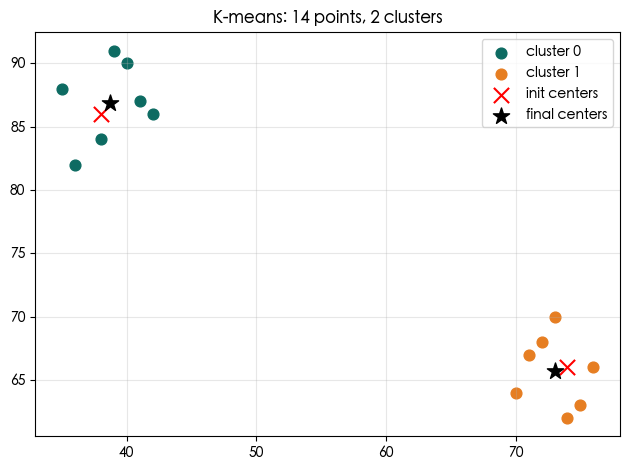

In [6]:
# 输出聚类中心、簇大小，并绘制 sklearn 模型结果。
display(kmeans_result_table(kmeans, labels))
plot_kmeans_model(kmeans, labels)